In [47]:
# Imports y configuración

import pandas as pd
import numpy as np
from pathlib import Path

import warnings
warnings.filterwarnings("ignore")

DATA_DIR = Path("../../data/dashboard")
VAL_DIR = DATA_DIR / "validation"
VAL_DIR.mkdir(parents=True, exist_ok=True)

RISK_FREE_ANNUAL = 0.03   # 3% anual
TRADING_DAYS = 252
rf_daily = (1 + RISK_FREE_ANNUAL)**(1/TRADING_DAYS) - 1


In [48]:
# Generate signals_raw.parquet using GLOBAL model for all tickers

import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Configurar rutas
DATA_DIR = Path("../../data")
(DATA_DIR / "model_results").mkdir(parents=True, exist_ok=True)

# Cargar datasets
print("Cargando datos...")
train = pd.read_parquet('./data/processed/ml_ready/train.parquet')
test = pd.read_parquet('./data/processed/ml_ready/test.parquet')

print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")

# Obtener lista de todos los tickers únicos
all_tickers = sorted(train['Ticker'].unique())
print(f"📊 Tickers encontrados: {len(all_tickers)}")
print(f"Tickers: {all_tickers}")

# Separar features y target
feature_cols = [col for col in train.columns if col not in ['Ticker', 'Date', 'Target']]
print(f"Features: {len(feature_cols)}")

X_train_full = train[feature_cols]
y_train = train['Target']
X_test_full = test[feature_cols]
y_test = test['Target']

print(f"X_train shape: {X_train_full.shape}")
print(f"X_test shape: {X_test_full.shape}")

# Entrenar modelo GLOBAL una vez
print("🎯 Entrenando modelo GLOBAL...")
scaler_rf = StandardScaler()
X_train_scaled_rf = scaler_rf.fit_transform(X_train_full)
X_test_scaled_rf = scaler_rf.transform(X_test_full)

pca_rf = PCA(n_components=5, random_state=42)
X_train_rf = pca_rf.fit_transform(X_train_scaled_rf)
X_test_rf = pca_rf.transform(X_test_scaled_rf)

# Modelo Global
model_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
model_rf.fit(X_train_rf, y_train)

print("✅ Modelo global entrenado")

# Hacer predicciones para todos los datos de test
print("🔮 Generando predicciones para todos los tickers...")
y_pred_rf_final = model_rf.predict(X_test_rf)
y_pred_proba_rf_final = model_rf.predict_proba(X_test_rf)[:, 1]

# Crear el DataFrame de señales completo
signals_all = test[['Date', 'Ticker']].copy()

# Buscar la columna de precio
price_col = None
for col in ['Close', 'Adj Close', 'close']:
    if col in test.columns:
        price_col = col
        break

if price_col:
    signals_all['close'] = test[price_col]
else:
    print("⚠️ No se encontró columna de precio, usando valores dummy")
    signals_all['close'] = 100.0

# CORRECCIÓN: Sintaxis correcta para rename
signals_all = signals_all.rename(columns={
    "Date": "date",
    "Ticker": "ticker"
})

signals_all['y_true'] = y_test.values
signals_all['y_proba'] = y_pred_proba_rf_final
signals_all['signal'] = y_pred_rf_final

# Convertir fecha
signals_all["date"] = pd.to_datetime(signals_all["date"])

# Guardar las señales generadas
signals_raw_path = DATA_DIR / "model_results" / "signals_raw.parquet"
signals_all.to_parquet(signals_raw_path, index=False)

print(f"\n🎉 PROCESAMIENTO COMPLETADO")
print(f"✅ Generated signals_raw.parquet at: {signals_raw_path}")
print(f"📊 Señales generadas: {len(signals_all)}")
print(f"📅 Rango de fechas: {signals_all['date'].min()} to {signals_all['date'].max()}")
print(f"🏷️  Tickers únicos: {signals_all['ticker'].nunique()}")
print(f"📈 Tickers procesados: {sorted(signals_all['ticker'].unique())}")

print("\n📋 Distribución de señales por ticker:")
signal_summary = signals_all.groupby('ticker')['signal'].value_counts().unstack(fill_value=0)
print(signal_summary)

print("\n📊 Distribución general de señales:")
print(signals_all['signal'].value_counts().sort_index())

print("\n👀 Primeras filas:")
print(signals_all.head(10))

Cargando datos...
Train shape: (20120, 25)
Test shape: (5040, 25)
📊 Tickers encontrados: 10
Tickers: ['AAPL', 'AMZN', 'GOOGL', 'JPM', 'META', 'MSFT', 'NVDA', 'TSLA', 'UNH', 'XOM']
Features: 22
X_train shape: (20120, 22)
X_test shape: (5040, 22)
🎯 Entrenando modelo GLOBAL...
✅ Modelo global entrenado
🔮 Generando predicciones para todos los tickers...

🎉 PROCESAMIENTO COMPLETADO
✅ Generated signals_raw.parquet at: ..\..\data\model_results\signals_raw.parquet
📊 Señales generadas: 5040
📅 Rango de fechas: 2022-12-29 00:00:00-05:00 to 2024-12-31 00:00:00-05:00
🏷️  Tickers únicos: 10
📈 Tickers procesados: ['AAPL', 'AMZN', 'GOOGL', 'JPM', 'META', 'MSFT', 'NVDA', 'TSLA', 'UNH', 'XOM']

📋 Distribución de señales por ticker:
signal    0    1
ticker          
AAPL     70  434
AMZN     76  428
GOOGL   109  395
JPM     182  322
META    201  303
MSFT    140  364
NVDA    125  379
TSLA    188  316
UNH     124  380
XOM     156  348

📊 Distribución general de señales:
signal
0    1371
1    3669
Name: cou

In [49]:
# Función de Backtesting Completa

def compute_backtesting(df_ticker: pd.DataFrame):
    df = df_ticker.sort_values("date").copy()

    df["ret_benchmark"] = df["close"].pct_change().fillna(0)

    # Usamos señal del día anterior
    df["position"] = df["signal"].shift(1).fillna(0)
    df["ret_strategy"] = df["position"] * df["ret_benchmark"]

    # Curvas acumuladas
    df["cum_strategy"] = (1 + df["ret_strategy"]).cumprod()
    df["cum_benchmark"] = (1 + df["ret_benchmark"]).cumprod()

    # Métricas
    excess = df["ret_strategy"] - rf_daily
    sharpe = np.sqrt(TRADING_DAYS) * excess.mean() / excess.std() if excess.std() > 0 else np.nan

    negative_excess = excess[excess < 0]
    downside_std = negative_excess.std()
    sortino = (np.sqrt(TRADING_DAYS) * excess.mean() / downside_std
               if downside_std and not np.isnan(downside_std) else np.nan)

    max_dd_strategy = (df["cum_strategy"] / df["cum_strategy"].cummax() - 1).min()
    max_dd_benchmark = (df["cum_benchmark"] / df["cum_benchmark"].cummax() - 1).min()

    metrics = pd.DataFrame({
        "metric": [
            "Sharpe",
            "Sortino",
            "Retorno total estrategia",
            "Retorno total buy & hold",
            "Max drawdown estrategia",
            "Max drawdown buy & hold"
        ],
        "strategy": [
            sharpe,
            sortino,
            df["cum_strategy"].iloc[-1] - 1,
            df["cum_benchmark"].iloc[-1] - 1,
            max_dd_strategy,
            max_dd_benchmark
        ]
    })

    return df, metrics

In [50]:
# Loop para todos los tickers

for ticker, df_t in signals_all.groupby("ticker"):
    print("Procesando:", ticker)

    bt_df, metrics_df = compute_backtesting(df_t)

    # Guardar curvas
    bt_df[["date", "cum_strategy", "cum_benchmark"]].to_csv(
        VAL_DIR / f"backtest_{ticker}.csv",
        index=False
    )

    # Guardar métricas
    metrics_df.to_csv(
        VAL_DIR / f"metrics_{ticker}.csv",
        index=False
    )



Procesando: AAPL
Procesando: AMZN
Procesando: GOOGL
Procesando: JPM
Procesando: META
Procesando: MSFT
Procesando: NVDA
Procesando: TSLA
Procesando: UNH
Procesando: XOM


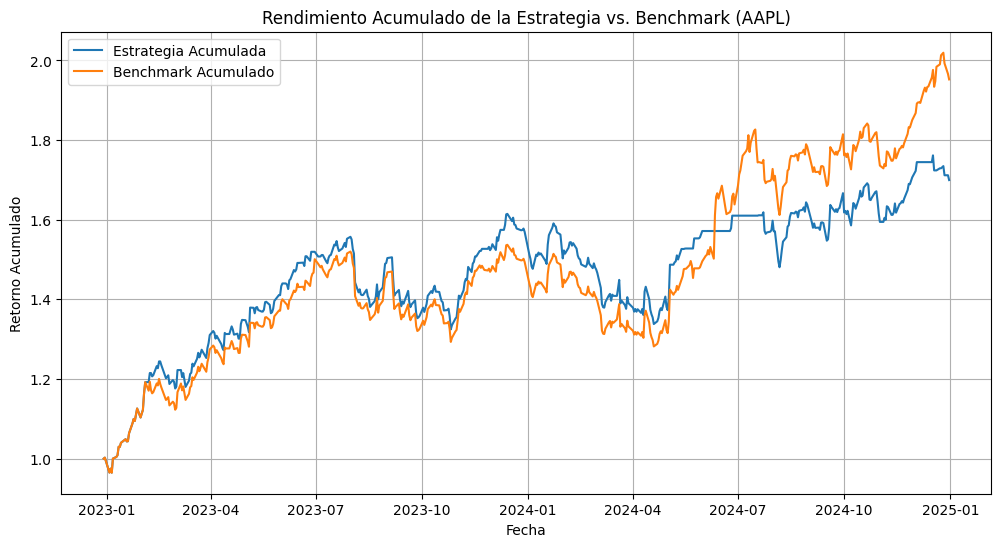

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

# Load the backtesting results for AAPL (as an example)
# You can change 'AAPL' to any other ticker if you wish
aapl_backtest = pd.read_csv(VAL_DIR / "backtest_AAPL.csv")
aapl_backtest['date'] = pd.to_datetime(aapl_backtest['date'])

plt.figure(figsize=(12, 6))
sns.lineplot(data=aapl_backtest, x='date', y='cum_strategy', label='Estrategia Acumulada')
sns.lineplot(data=aapl_backtest, x='date', y='cum_benchmark', label='Benchmark Acumulado')
plt.title('Rendimiento Acumulado de la Estrategia vs. Benchmark (AAPL)')
plt.xlabel('Fecha')
plt.ylabel('Retorno Acumulado')
plt.legend()
plt.grid(True)
plt.show()

In [52]:
# Guardar señales unificadas

signals_all.to_parquet(
    VAL_DIR / "signals_all_tickers.parquet",
    index=False,
    engine="fastparquet"
)
signals_all.shape



(5040, 6)

In [54]:
# ROC curve y reporte

from sklearn.metrics import roc_curve, classification_report

roc_list = []
metrics_list = []

for ticker, df_t in signals_all.groupby("ticker"):

    y_true = df_t["y_true"]
    y_proba = df_t["y_proba"]
    y_pred = (df_t["y_proba"] >= 0.5).astype(int)

    fpr, tpr, _ = roc_curve(y_true, y_proba)
    df_roc = pd.DataFrame({"ticker": ticker, "fpr": fpr, "tpr": tpr})
    roc_list.append(df_roc)

    report = classification_report(y_true, y_pred, output_dict=True)
    rep_df = pd.DataFrame(report).T
    rep_df["ticker"] = ticker
    metrics_list.append(rep_df)

roc_df = pd.concat(roc_list)
metrics_df = pd.concat(metrics_list)

roc_df.to_csv(DATA_DIR / "model_results" / "roc_curve.csv", index=False)
metrics_df.to_csv(DATA_DIR / "model_results" / "classification_metrics.csv")


In [55]:
metrics_unh = pd.read_csv(VAL_DIR / "metrics_UNH.csv")
display(metrics_unh)

,metric,strategy
0,Sharpe,-0.303653
1,Sortino,-0.373920
2,Retorno total estrategia,-0.122224
3,Retorno total buy & hold,-0.015786
4,Max drawdown estrategia,-0.230675
5,Max drawdown buy & hold,-0.220500


In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Imported matplotlib.pyplot and seaborn.")

Imported matplotlib.pyplot and seaborn.


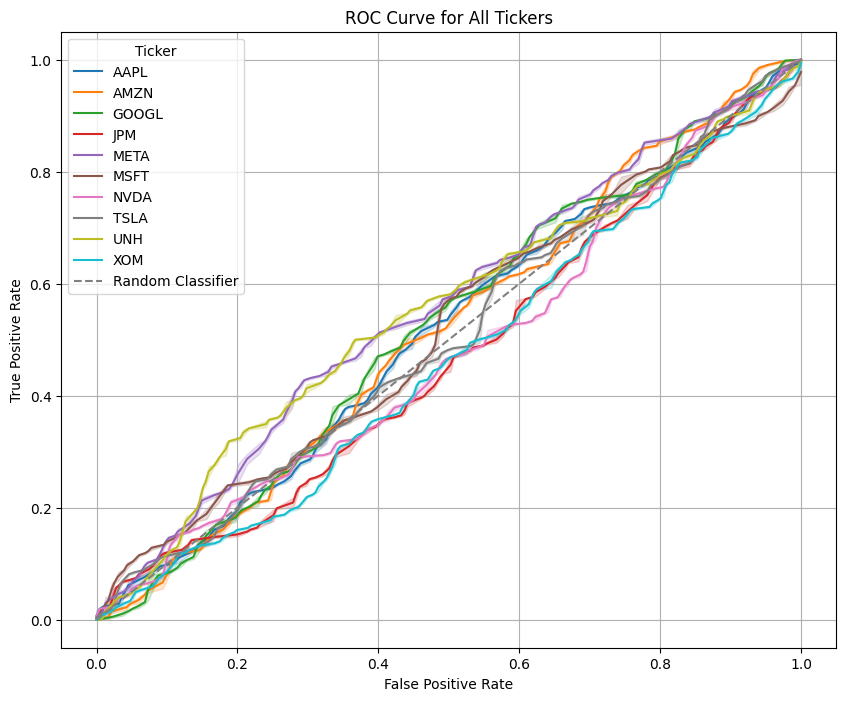

In [ ]:
plt.figure(figsize=(10, 8))
sns.lineplot(data=roc_df, x='fpr', y='tpr', hue='ticker')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for All Tickers')
plt.legend(title='Ticker')
plt.grid(True)
plt.show()